# 1.Instagram GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [1]:
import pandas as pd
import networkx as nx
from itertools import combinations

df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/instagram_graph.csv"
)
print("INSTAGRAM GRAPH DATA")
print(df.shape)

INSTAGRAM GRAPH DATA
(30195, 30)


In [2]:
import pandas as pd
import numpy as np
import time

overall_start = time.time()
# 1. GENERATE NODES
nodes_df = df.copy().rename(columns={"post_id": "Id"})
nodes_df["Label"] = nodes_df["Id"]
nodes_df.to_csv("insta_node.csv", index=False, encoding='utf-8')

# 2. GENERATE EDGES (INSTAGRAM MULTIMODAL HOMOPHILY)
edges_list = []
sorted_df = df.sort_values(by=['account_age_days'], ascending=True)

# --- A. Catégories (CATEGORICAL HOMOPHILY) ---
cat_features = ['topic', 'media_type', 'language']

for feat in cat_features:
    if feat not in sorted_df.columns: continue
    print(f"Processing Categorical Homophily: {feat}...")
    
    for val, group in sorted_df.groupby(feat):
        if pd.isna(val): continue
        ids = group['post_id'].values
        if len(ids) < 2: continue
        
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.2, 
                "Relation": feat
            })

# --- B. BINARY/STATUS ---
bin_features = ['verified', 'high_toxicity']

for feat in bin_features:
    if feat not in sorted_df.columns: continue
    print(f"Processing Binary/Status Homophily: {feat}...")
    active_group = sorted_df[sorted_df[feat] == 1]
    ids = active_group['post_id'].values
    
    if len(ids) < 2: continue
    for i in range(len(ids) - 1):
        edges_list.append({
            "Source": ids[i], 
            "Target": ids[i+1],
            "Weight": 1.0, 
            "Relation": feat
        })

# --- C. SENTIMENT HOMOPHILY ---
if 'sentiment_intensity' in sorted_df.columns:
    print("Processing Sentiment Vibe Homophily...")
    temp_df = sorted_df.copy()
    temp_df['sentiment_bins'] = temp_df['sentiment_intensity'].round(1) 
    
    for val, group in temp_df.groupby('sentiment_bins'):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 0.8, 
                "Relation": "sentiment_vibe"
            })

# --- D. USER-ID ---
print("Processing Instagram Author Bridges...")
for user_id, group in sorted_df.groupby('user_id'):
    ids = group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 2.5, 
                "Relation": "same_author"
            })

edges_df = pd.DataFrame(edges_list)
if not edges_df.empty:
    edges_df[['Source', 'Target']] = np.sort(edges_df[['Source', 'Target']], axis=1)
    edges_df = edges_df.drop_duplicates(subset=['Source', 'Target', 'Relation'])
    edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

edges_df.to_csv("insta_edge.csv", index=False, encoding='utf-8')

print(f"\n---INSTAGRAM GRAPH ---")
print(f"Nodes: {len(nodes_df):,}")
print(f"Edges: {len(edges_df):,}")
print(f"Time: {round(time.time() - overall_start, 2)}s")

Processing Categorical Homophily: topic...
Processing Categorical Homophily: media_type...
Processing Categorical Homophily: language...
Processing Binary/Status Homophily: verified...
Processing Binary/Status Homophily: high_toxicity...
Processing Sentiment Vibe Homophily...
Processing Instagram Author Bridges...

---INSTAGRAM GRAPH ---
Nodes: 30,195
Edges: 124,460
Time: 4.35s


In [5]:
import pandas as pd

graph_df = pd.read_csv(
    "insta-result-11.csv"
)

print(graph_df.shape)

print("\nColumns:")
print(graph_df.columns.tolist())

(30195, 45)

Columns:
['Id', 'platform', 'hour_of_day', 'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days', 'verified', 'topic', 'language', 'content_length', 'media_type', 'num_hashtags', 'sentiment_category', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'toxicity_score', 'location', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'has_media', 'many_hashtags', 'long_content', 'sentiment_intensity', 'high_toxicity', 'popularity', 'Degree', 'Weighted Degree', 'Eccentricity', 'closnesscentrality', 'harmonicclosnesscentrality', 'betweenesscentrality', 'Authority', 'Hub', 'pageranks', 'modularity_class', 'stat_inf_class', 'clustering', 'triangles', 'eigencentrality', 'componentnumber']


In [6]:
graph_features = graph_df[[
    "Id",
    "betweenesscentrality",
    "eigencentrality",
    "pageranks",
    "Weighted Degree",
    "modularity_class",
    "Degree"
]]
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

print("\nGraph Features Shape:")
print(graph_features.shape)



Graph Features Shape:
(30195, 7)


In [7]:
original_df = df.copy()
original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [8]:
metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [9]:
train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/instagram_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/instagram_test.csv"
)


print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape: (24156, 56)
Test Shape : (6039, 56)


In [10]:
train_hybrid = train_df.merge(
    graph_features,
    on="post_id",
    how="left"
)

test_hybrid = test_df.merge(
    graph_features,
    on="post_id",
    how="left"
)

In [16]:
print("\n" + "="*30)
print("TRAIN CLASS DISTRIBUTION")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nProportion %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("TEST CLASS DISTRIBUTION")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nProportion %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


TRAIN CLASS DISTRIBUTION
popularity
0    19313
1     4843
Name: count, dtype: int64

Proportion %:
popularity
0    79.951151
1    20.048849
Name: proportion, dtype: float64

TEST CLASS DISTRIBUTION
popularity
0    4828
1    1211
Name: count, dtype: int64

Proportion %:
popularity
0    79.947011
1    20.052989
Name: proportion, dtype: float64


In [15]:
negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"scale_pos_weight = {ratio:.2f}")

scale_pos_weight = 3.99


In [78]:
numeric_graph_cols = [
    "betweenesscentrality",
    "eigencentrality",
    "pageranks",
    "Degree",
    "Weighted Degree"
]

existing_numeric_cols = [col for col in numeric_graph_cols if col in train_hybrid.columns]

if "modularity_class" in train_hybrid.columns:
    train_hybrid["modularity_class"] = train_hybrid["modularity_class"].fillna(-1)
    test_hybrid["modularity_class"]  = test_hybrid["modularity_class"].fillna(-1)

train_hybrid[existing_numeric_cols] = train_hybrid[existing_numeric_cols].fillna(0)
test_hybrid[existing_numeric_cols]  = test_hybrid[existing_numeric_cols].fillna(0)

X_train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=X_train_cols, fill_value=0)


print("HYBRID DATASETS ")
print(f"Train Hybrid: {train_hybrid.shape}")
print(f"Test Hybrid : {test_hybrid.shape}")

HYBRID DATASETS 
Train Hybrid: (24156, 62)
Test Hybrid : (6039, 62)


In [79]:
for df_tmp in [train_hybrid, test_hybrid]:
    if "modularity_class" in df_tmp.columns:
        df_tmp["modularity_class"] = "comm_" + df_tmp["modularity_class"].astype(str)

categorical_cols = ["topic", "language", "media_type", "sentiment_category", "location", "modularity_class"]

existing_cats = [col for col in categorical_cols if col in train_hybrid.columns]
train_hybrid = pd.get_dummies(train_hybrid, columns=existing_cats, drop_first=True, dtype=int)
test_hybrid = pd.get_dummies(test_hybrid, columns=existing_cats, drop_first=True, dtype=int)

train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=train_cols, fill_value=0)

print(f"Number of features: {train_hybrid.shape[1]}")

Number of features: 119


In [80]:
train_hybrid.to_csv(
    "instagram_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "instagram_hybrid_test.csv",
    index=False
)

In [81]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [82]:
train_df = pd.read_csv(
    "instagram_hybrid_train.csv"
)

test_df = pd.read_csv(
    "instagram_hybrid_test.csv"
)

print("HYBRID DATASETS")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (24156, 119)
Test Shape : (6039, 119)


In [83]:
drop_cols = [
    "post_id",
    "user_id"
]

existing_drop_cols = [
    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [84]:
X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (24156, 116)
X_test Shape : (6039, 116)


In [85]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     
    n_estimators=500,           
    learning_rate=0.02,         
    max_depth=6,                
    min_child_weight=1,         
    gamma=0.1,                  
    subsample=0.8,              
    colsample_bytree=0.5,       
    random_state=42,            
    n_jobs=-1                   
)

In [86]:
print("TRAINING HYBRID MODEL...")
model.fit(
    X_train,
    y_train
)

TRAINING HYBRID MODEL...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [87]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [88]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [89]:
print("CLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(f"ROC-AUC  : {roc_auc:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      4828
           1       0.48      0.75      0.59      1211

    accuracy                           0.79      6039
   macro avg       0.71      0.78      0.72      6039
weighted avg       0.84      0.79      0.80      6039

ROC-AUC  : 0.8687


In [90]:
cm = confusion_matrix(
    y_test,
    y_pred
)
print("CONFUSION MATRIX")

print(cm)

CONFUSION MATRIX
[[3859  969]
 [ 299  912]]


In [92]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("TOP 15 IMPORTANT FEATURES")
print(
    importance_df.head(15)
)

TOP 15 IMPORTANT FEATURES
                     feature  importance
3                  followers    0.148064
5                   verified    0.042647
19             high_toxicity    0.025763
56           Weighted Degree    0.014982
79  modularity_class_comm_29    0.010538
64  modularity_class_comm_15    0.009988
81  modularity_class_comm_30    0.009587
70  modularity_class_comm_20    0.009237
57                    Degree    0.009097
24             topic_Fashion    0.008928
69   modularity_class_comm_2    0.008832
82  modularity_class_comm_31    0.008827
72  modularity_class_comm_22    0.008550
10            toxicity_score    0.008429
86  modularity_class_comm_35    0.008364


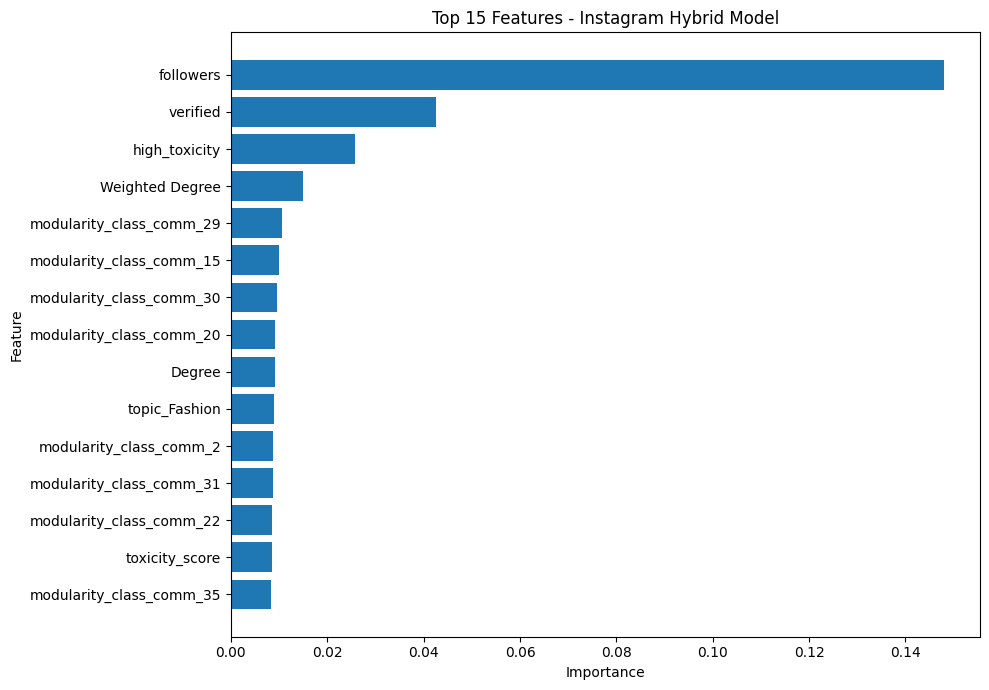

In [93]:
import matplotlib.pyplot as plt

top_n = 15
plot_df = importance_df.head(top_n)
plt.figure(figsize=(10, 7))
plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features - Instagram Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. INSTAGRAM NODE2VEC

 GRAPH EMBEDDING

In [17]:
import pandas as pd
import os
import networkx as nx

import time

start_time = time.time()
edges_df = pd.read_csv("insta_edge.csv") 

G = nx.from_pandas_edgelist(
    edges_df, 
    source="Source", 
    target="Target", 
    create_using=nx.Graph() 
)

print(f"Graph Created | Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}")



number_cpu = os.cpu_count()
print(f"Number of CPU cores: {number_cpu} ")





Graph Created | Nodes: 30,195 | Edges: 108,162
Number of CPU cores: 22 


In [18]:
from node2vec import Node2Vec
import time

node2vec = Node2Vec(
    G,
    dimensions=8,        
    walk_length=10,      
    num_walks=20,        
    workers=number_cpu,  
    seed=42,
    quiet=False          
)

model = node2vec.fit(
    window=5, 
    min_count=1, 
    batch_words=4     
)

print("\nNode2Vec completed")

print(f"\nNode2Vec completed after: {round((time.time() - start_time)/60, 2)} minutes ")



Computing transition probabilities:   0%|          | 0/30195 [00:00<?, ?it/s]


Node2Vec completed

Node2Vec completed after: 11.55 minutes 


In [19]:
print("Extracting Embeddings into DataFrame...")
node_ids = list(model.wv.index_to_key)
embeddings = model.wv.vectors

emb_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(8)])
emb_df["post_id"] = node_ids 
emb_df = emb_df[emb_df['post_id'].astype(str).str.startswith('INS')]

emb_df.to_csv("instagram_node2vec_8dims.csv", index=False)
print(f"Successfully saved {len(emb_df)} post vectors.")

Extracting Embeddings into DataFrame...
Successfully saved 30195 post vectors.


In [20]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)


In [21]:
train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/instagram_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/instagram_test.csv"
)

print("METADATA DATA")

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATA
Train Shape: (24156, 56)
Test Shape : (6039, 56)


In [22]:
#LOAD NODE2VEC EMBEDDINGS
embedding_df = pd.read_csv(
    "instagram_node2vec_8dims.csv"
)
print("NODE2VEC EMBEDDINGS")
print(embedding_df.shape)

print("\nEmbedding Columns:")
print(embedding_df.columns[:10])

NODE2VEC EMBEDDINGS
(30195, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='str')


In [23]:
train_hybrid = train_df.merge(
    embedding_df,
    on="post_id",
    how="left"
)

test_hybrid = test_df.merge(
    embedding_df,
    on="post_id",
    how="left"
)

In [24]:
print("MISSING EMBEDDINGS CHECK")
embedding_cols = [
    col for col in embedding_df.columns
    if col.startswith("emb_")
]

print("\nTrain Missing:")
print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")
print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

drop_cols = [
    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)

MISSING EMBEDDINGS CHECK

Train Missing:
0

Test Missing:
0


In [25]:
X_train = train_hybrid.drop(
    columns=["popularity"]
)

y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)
y_test = test_hybrid["popularity"]

print("FINAL DATA")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


FINAL DATA
X_train: (24156, 61)
X_test : (6039, 61)


In [31]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,      
    n_estimators=300,            
    learning_rate=0.03,         
    max_depth=6,                
    subsample=0.8,               
    colsample_bytree=0.5,        
    reg_alpha=0.5,               
    reg_lambda=1.5,              
    random_state=42,
    n_jobs=-1
)

In [32]:
print("TRAINING NODE2VEC HYBRID MODEL...")

model.fit(
    X_train,
    y_train
)
print("Training completed")

TRAINING NODE2VEC HYBRID MODEL...
Training completed


In [33]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [34]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [35]:
print("CLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      4828
           1       0.49      0.76      0.59      1211

    accuracy                           0.79      6039
   macro avg       0.71      0.78      0.73      6039
weighted avg       0.84      0.79      0.81      6039

ROC-AUC  : 0.8681


In [36]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("TOP 20 IMPORTANT FEATURES")
print(
    importance_df.head(20)
)

TOP 20 IMPORTANT FEATURES
                feature  importance
3             followers    0.268513
5              verified    0.135199
24        topic_Fashion    0.012813
22      topic_Education    0.012423
33         topic_Travel    0.012189
10       toxicity_score    0.012081
23  topic_Entertainment    0.011828
9    sentiment_negative    0.011786
20       topic_Business    0.011760
54                emb_1    0.011650
56                emb_3    0.011436
53                emb_0    0.011278
58                emb_5    0.011266
19        high_toxicity    0.011191
60                emb_7    0.011076
46     media_type_Video    0.011076
50     location_Oceania    0.010987
57                emb_4    0.010947
6        content_length    0.010947
8    sentiment_positive    0.010926


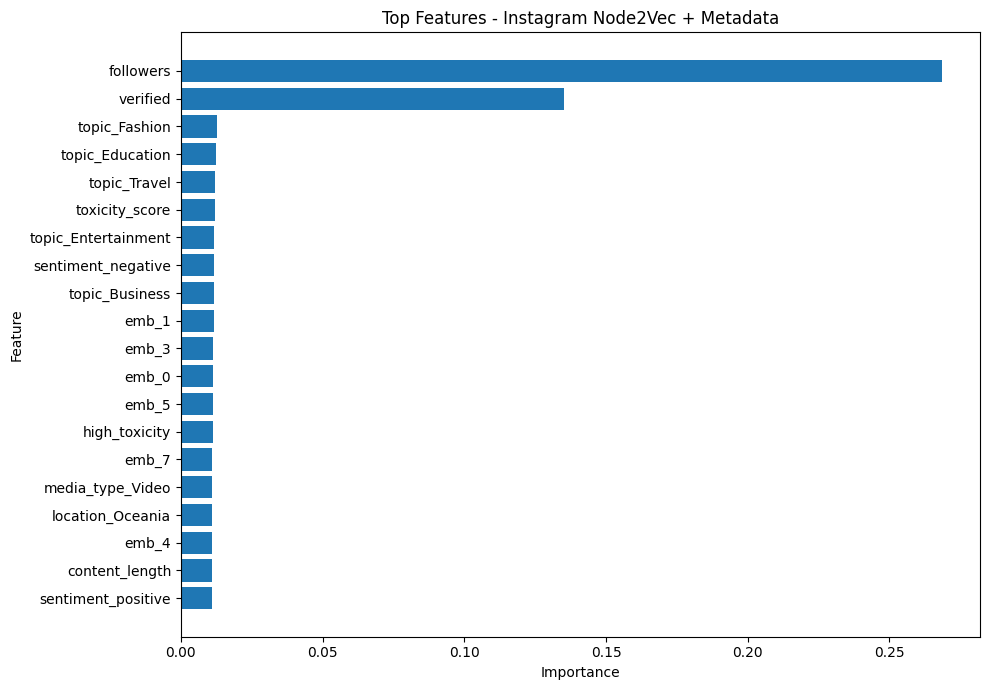

In [37]:
import matplotlib.pyplot as plt
top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - Instagram Node2Vec + Metadata"
)

plt.tight_layout()

plt.show()

# 3. Instagram graph + Node2vector

In [38]:
selected_n2v = ["emb_0", "emb_6", "emb_3", "emb_4", "emb_1"]
embedding_df_filtered = embedding_df[["post_id"] + [c for c in selected_n2v if c in embedding_df.columns]]

print(f"Selected columns: {embedding_df_filtered.columns.tolist()}")

Selected columns: ['post_id', 'emb_0', 'emb_6', 'emb_3', 'emb_4', 'emb_1']


In [39]:
train_df = pd.read_csv(
    "instagram_hybrid_train.csv"
)

test_df = pd.read_csv(
    "instagram_hybrid_test.csv"
)

print("GRAPH HYBRID DATA")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

print("\nNODE2VEC EMBEDDINGS")
print(embedding_df.shape)


print("\nEmbedding Columns:")
print(embedding_df.columns)

GRAPH HYBRID DATA
Train Shape: (24156, 119)
Test Shape : (6039, 119)

NODE2VEC EMBEDDINGS
(30195, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='str')


In [40]:
train_final = train_df.merge(embedding_df_filtered, on="post_id", how="left")
test_final = test_df.merge(embedding_df_filtered, on="post_id", how="left")
print(f"Train Shape: {train_final.shape} | Test Shape: {test_final.shape}")

Train Shape: (24156, 124) | Test Shape: (6039, 124)


In [41]:
actual_emb_cols = [col for col in train_final.columns if col.startswith("emb_")]
train_final[actual_emb_cols] = train_final[actual_emb_cols].fillna(0)
test_final[actual_emb_cols] = test_final[actual_emb_cols].fillna(0)

print(f"Missing values after fill: {train_final[actual_emb_cols].isnull().sum().sum()}")

Missing values after fill: 0


In [42]:
drop_cols = ["post_id", "user_id"]
existing_drop_cols = [col for col in drop_cols if col in train_final.columns]

train_final = train_final.drop(columns=existing_drop_cols)
test_final = test_final.drop(columns=existing_drop_cols)

print(f"Final features: {train_final.shape[1]} features.")

Final features: 122 features.


In [43]:
X_train = train_final.drop(
    columns=["popularity"]
)

y_train = train_final["popularity"]

X_test = test_final.drop(
    columns=["popularity"]
)

y_test = test_final["popularity"]
print("FINAL FEATURE SPACE")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

FINAL FEATURE SPACE
X_train: (24156, 121)
X_test : (6039, 121)


In [44]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,      
    n_estimators=500,            
    learning_rate=0.03,          
    max_depth=6,                 
    subsample=0.8,               
    colsample_bytree=0.5,        
    reg_alpha=0.5,               
    reg_lambda=1.5,              
    random_state=42,
    n_jobs=-1
)


In [45]:
print("TRAINING FINAL INSTAGRAM META + GRAPH + EMBEDDING...")
model.fit(
    X_train,
    y_train
)
print("\nTraining completed ")

TRAINING FINAL INSTAGRAM META + GRAPH + EMBEDDING...

Training completed 


In [46]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [47]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


In [48]:
print("CLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      4828
           1       0.49      0.73      0.59      1211

    accuracy                           0.80      6039
   macro avg       0.71      0.77      0.73      6039
weighted avg       0.84      0.80      0.81      6039

ROC-AUC  : 0.8657


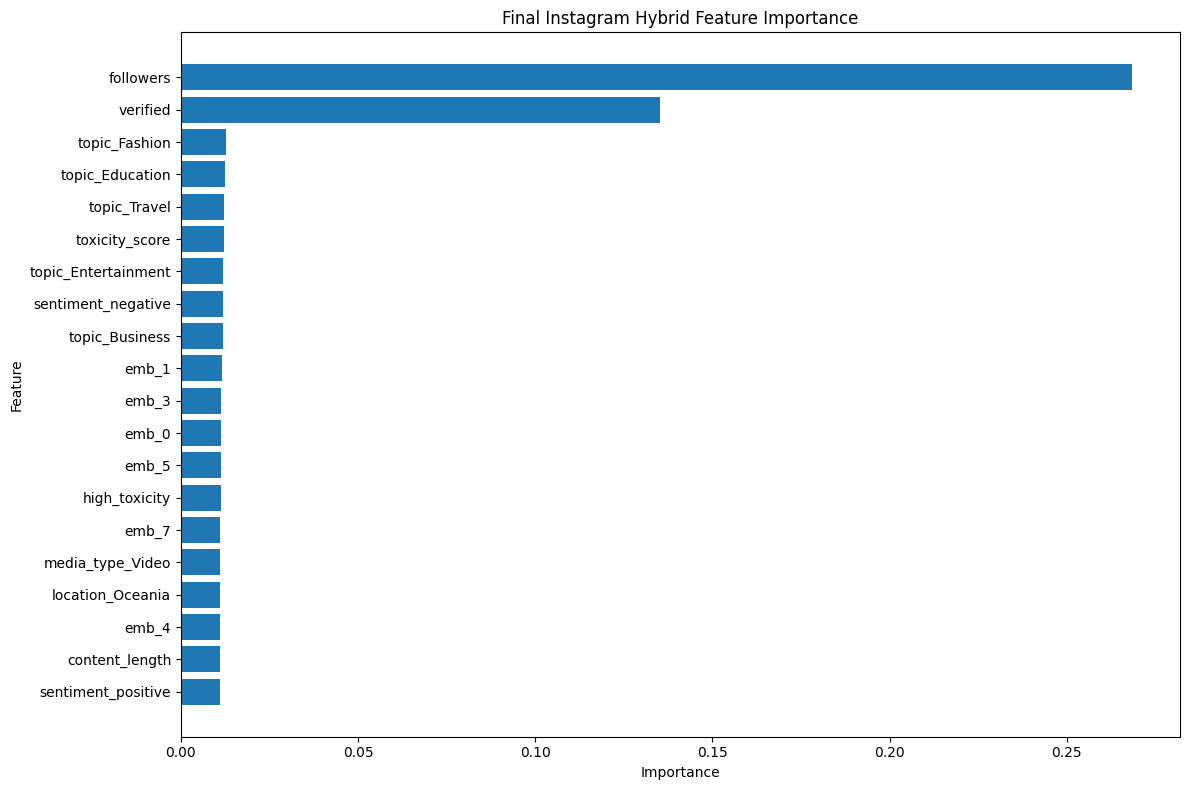

In [49]:
top_n = 20
plot_df = importance_df.head(top_n)

plt.figure(figsize=(12, 8))
plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    "Final Instagram Hybrid Feature Importance"
)
plt.tight_layout()
plt.show()